In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [3]:
from collections import deque
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import plotly.express as px
import sys
import tifffile as tf
import torch
from typing import Dict, Literal, Tuple, Union

sys.path.append("..")
from data_prep import load
from neurotrack.data.neuron_data import Dataset, DataLoader
from neurotrack.data import DataGenerator, DrawingComplexityConfig
from plot import tracking_interface
from data_prep.image import Image
from environments import tracking_reward
from environments.neuron_tracking_environment_v2 import NeuronTrackingEnvironment, create_neuron_tracking_environment

device = "cpu"
dtype = torch.float32

Distance Reward:

Start
- Set target step size in pixels, dt = 4.
- Assign seed point for each path, $p_{i,0}$ (I will assume there is one path going forward for simplicity).
- Find nearest position to $p_0$ on the whole tree, $x_0$.
- Find the nearest node to $x_0$.
- Instantiate visited edge dictionary
- Add the length from the nearest node to $x_0$ to visited.
- Create a modified neuron tree with the visted neuron removed.
- Compute target_termination_nodes for $p_0$
- For each step:
  - Decide if the path terminates.
  - If it does not terminate:
    - Compute target point or points by traversing along the modified tree from $x_t$ by a distance of dt.
      - Usually there will be only one direction to traverse to find the target point, but when there are branches
        there could be multiple potential targets. In that case the nearest target to the next step will
        determine the reward.
    - Find the distance between the new position to the nearest target point. Reward is the negative squared distance.
    - Find $x_t$, the nearest position on the modified tree to the new path position.
    - Remove the length of neuron between $x_{t-1}$ and $x_t$ from the modified neuron tree.
  - If the path terminated:
    - Get the distance to the nearest termination point for the path.
    - Reward is the negative squared distance times $\frac{1}{1 - \gamma}$.

Area of error reward:

Start
- assign seed point, $p_0$
- find nearest position to $p_0$ on the whole tree, $x_0$
- get section to which $x_0$ belongs, $S_i$
- get end points of $S_i$
- t = 0
- while path is not terminated
  - take step
  - t += 1
  - if the path does not terminate
    - add new position, $p_t$ to estimated path
    - find nearest position to $p_t$ on the whole neuron, $x_t$ 
    - find path on the neuron between $x_{t-1}$ and $x_t$
    - divide the path into its edges (segments between nodes on the neuron path)
    - for each neuron path edge, $e$, and the last step on the estimated path, p:
      - compute A = $\int_{s=0}^1 \min_{t\in[0,1]}||e(s) - p(t)||ds$
      - This will have to be done by discretizing the edge and computing a discrete sum over distances.
    - compute $\Delta x$, the distance traversed along the neuron by the step, i.e. from the previous nearest point to the new nearest point on the neuron.\
      $\Delta x = max(\Delta x, \Delta p)$, where $\Delta p$ is the step size, $|p_{t} - p_{t-1}|$. This is so that the agent can't cut corners and cover\
      more distance on the neuron than the size of the step.
    - reward = $\Delta x^2 - 2A$.
      The reward is the difference between the squared length of neuron covered and the area of error.\
      This way the reward is positive if the step is close to the neuron and negative if it is far, with the magnitude of the reward increasing quadratically if it is a longer step (assuming the neuron is straight).
    - find nearest position on whole tree to the new point and assign it to the new section id

Why use the area rather than just the squared distance between the new position and the target position? Because using only the target position could incentivize the neuron to cut\
corners. This also allows it to learn to take variable step sizes depending on what's most appropriate. The positive reward incentivizes it to move forward.

Few more things:

- Sometimes a neuron tree has disconnected sections because the soma was removed. What happens if the new point is disconnected from the previous section?
- Termination:
  - Best if it terminates if it takes a step shorter than a certain threshold. That way it can't hack by taking very small steps and observing very small costs,\
    especially when starting at potential branch points where the goal is to terminate if there is no branch nearby. 
  - The termination reward will be the negative squared distance between the current position and the closest target end point.\
    This distance may need to be carefully defined as the distance from the current position to the nearest point on the current section ($|p_t - x_t|$) plus the distance of traversal along\
    the neuron from $x_t$ to the nearest (by traversal) endpoint. Using simply the euclidean distance could lead to undesired behavior if the neuron curls around so the\
    end is close to upstream points. However, since the maximum reward for terminating is 0 and stepping in the correct direction can return positive reward, it may still\
    learn to step rather than terminate in those cases, so we won't worry about it for now. 

In [14]:
# Test _init_visited, _add_to_visited, and _get_swc_sans_visited functions
# straight line SWC
line_swc = np.array([[1, 3, 0.0, 0.0, 0.0, 1.0, -1],
                     [2, 3, 10.0, 0.0, 0.0, 1.0, 1],
                     [3, 3, 20.0, 0.0, 0.0, 1.0, 2]])

disconnected_swc = np.array([[1, 3, 0.0, 0.0, 0.0, 1.0, -1],
                              [2, 3, 10.0, 0.0, 0.0, 1.0, 1],
                              [3, 3, 20.0, 0.0, 0.0, 1.0, 2],
                              [4, 3, 0.0, 10.0, 0.0, 1.0, -1],
                              [5, 3, 10.0, 10.0, 0.0, 1.0, 4],
                              [6, 3, 20.0, 10.0, 0.0, 1.0, 5]])

branched_swc = np.array([[1, 3, 0.0, 0.0, 0.0, 1.0, -1],
                         [2, 3, 10.0, 0.0, 0.0, 1.0, 1],
                         [3, 3, 20.0, 0.0, 0.0, 1.0, 2],
                         [4, 3, 10.0, 10.0, 0.0, 1.0, 2],
                         [5, 3, 20.0, 10.0, 0.0, 1.0, 4]])


In [15]:
point = np.array([5.0, 0.0, 0.0])
segment_start = np.array([0.0, 0.0, 0.0])
segment_end = segment_start
dist, closest_point = tracking_reward._distance_points_to_segment(point, segment_start, segment_end)
print(f"Distance from point {point} to degenerate segment is {dist[0]}, closest point is {closest_point[0]}")

segment_end = np.array([10.0, 0.0, 0.0])
dist, closest_point = tracking_reward._distance_points_to_segment(point, segment_start, segment_end)
print(f"Distance from point {point} to segment is {dist[0]}, closest point is {closest_point[0]}")


Distance from point [5. 0. 0.] to degenerate segment is 5.0, closest point is tensor([0., 0., 0.])
Distance from point [5. 0. 0.] to segment is 0.0, closest point is tensor([5., 0., 0.])


In [20]:
print(line_swc)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(line_swc)}
edge_list = load.undirected_edge_list(line_swc)
visited = tracking_reward._init_visited(line_swc)
print(visited)
# step from midpoint to midpoint of edges
visited = tracking_reward._add_to_visited(np.array([-0.1, 0.5, 0.0]), np.array([3.0, 0.5, 0.0]), line_swc, visited, id_to_idx=id_to_idx)
print(visited)
new_swc, visited, edge_list = tracking_reward.remove_visited(line_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
print(new_swc)
print(visited)

[[ 1.  3.  0.  0.  0.  1. -1.]
 [ 2.  3. 10.  0.  0.  1.  1.]
 [ 3.  3. 20.  0.  0.  1.  2.]]
{(1, 2): 0.0, (2, 3): 0.0}
{(1, 2): 0.3, (2, 3): 0.0}
[[ 2.  3. 10.  0.  0.  1.  4.]
 [ 3.  3. 20.  0.  0.  1.  2.]
 [ 4.  3.  3.  0.  0.  1. -1.]]
{(2, 3): 0.0, (2, 4.0): 0.0}


In [22]:
print(disconnected_swc)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(disconnected_swc)}
edge_list = load.undirected_edge_list(disconnected_swc)
visited = tracking_reward._init_visited(disconnected_swc)
print(visited)
# step from midpoint of first line to midpoint of second line
visited = tracking_reward._add_to_visited(np.array([11.0, 0.0, 0.0]), np.array([15.0, 10.0, 0.0]), disconnected_swc, visited, id_to_idx=id_to_idx)
print(visited)
new_swc, visited, edge_list = tracking_reward.remove_visited(disconnected_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
print(new_swc)
print(visited)

[[ 1.  3.  0.  0.  0.  1. -1.]
 [ 2.  3. 10.  0.  0.  1.  1.]
 [ 3.  3. 20.  0.  0.  1.  2.]
 [ 4.  3.  0. 10.  0.  1. -1.]
 [ 5.  3. 10. 10.  0.  1.  4.]
 [ 6.  3. 20. 10.  0.  1.  5.]]
{(1, 2): 0.0, (2, 3): 0.0, (4, 5): 0.0, (5, 6): 0.0}
{(1, 2): 0.0, (2, 3): -0.9, (4, 5): 0.0, (5, 6): -0.5}
[[ 1.  3.  0.  0.  0.  1. -1.]
 [ 2.  3. 10.  0.  0.  1.  1.]
 [ 4.  3.  0. 10.  0.  1. -1.]
 [ 5.  3. 10. 10.  0.  1.  4.]
 [ 7.  3. 11.  0.  0.  1.  2.]
 [ 8.  3. 15. 10.  0.  1.  5.]]
{(1, 2): 0.0, (4, 5): 0.0, (2, 7.0): 0.0, (5, 8.0): 0.0}


In [25]:
print(branched_swc)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(branched_swc)}
edge_list = load.undirected_edge_list(branched_swc)

visited = tracking_reward._init_visited(branched_swc)
print(f"Initial visited: {visited}\n")

# step from midpoint of main branch to end of branch
start = np.array([5.0, 0.0, 0.0])
end = np.array([15.0, 10.0, 0.0])
visited = tracking_reward._add_to_visited(start, end, branched_swc, visited, id_to_idx=id_to_idx)
print(f"Updated visited (pre-remove): {visited}")
new_swc, visited, edge_list = tracking_reward.remove_visited(branched_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(new_swc)}
print(new_swc)
print(f"Updated visited (post-remove): {visited}\n")

start = end
end = np.array([15.0, -1.0, 0.0])
visited = tracking_reward._add_to_visited(start, end, new_swc, visited, id_to_idx=id_to_idx)
print(f"Updated visited (pre-remove): {visited}")
new_swc, visited, edge_list = tracking_reward.remove_visited(new_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(new_swc)}
print(new_swc)
print(f"Updated visited (post-remove): {visited}\n")

target_points = tracking_reward._compute_target_point(end, new_swc, 4.0, id_to_idx=id_to_idx)


# third step visits the end half of the main branch
start = end
end = np.array([25.0, -1.0, 0.0])
visited = tracking_reward._add_to_visited(start, end, new_swc, visited, id_to_idx=id_to_idx)
print(f"Updated visited (pre-remove): {visited}")
new_swc, visited, edge_list = tracking_reward.remove_visited(new_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(new_swc)}
print(new_swc)
print(f"Updated visited (post-remove): {visited}\n")

target_points = tracking_reward._compute_target_point(end, new_swc, 4.0, id_to_idx=id_to_idx)

# fourth step visits the rest of the main branch
start = end
end = np.array([0.0, -1.0, 0.0])
visited = tracking_reward._add_to_visited(start, end, new_swc, visited, id_to_idx=id_to_idx)
print(f"Updated visited (pre-remove): {visited}")
new_swc, visited, edge_list = tracking_reward.remove_visited(new_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(new_swc)}
print(new_swc)
print(f"Updated visited (post-remove): {visited}\n")

target_points = tracking_reward._compute_target_point(end, new_swc, 4.0, id_to_idx=id_to_idx)

# final step to test when everything is already visited
start = end
end = np.array([4.0, -1.0, 0.0])
visited = tracking_reward._add_to_visited(start, end, new_swc, visited, id_to_idx=id_to_idx)
print(f"Updated visited (pre-remove): {visited}")
new_swc, visited, edge_list = tracking_reward.remove_visited(new_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(new_swc)}
print(new_swc)
print(f"Updated visited (post-remove): {visited}\n")

target_points = tracking_reward._compute_target_point(end, new_swc, 4.0, id_to_idx=id_to_idx)

start = end
end = np.array([6.0, -1.0, 0.0])
visited = tracking_reward._add_to_visited(start, end, new_swc, visited, id_to_idx=id_to_idx)
print(f"Updated visited (pre-remove): {visited}")
new_swc, visited, edge_list = tracking_reward.remove_visited(new_swc, visited, edge_list=edge_list, id_to_idx=id_to_idx)
id_to_idx = {int(row[0]): idx for idx, row in enumerate(new_swc)}
print(new_swc)
print(f"Updated visited (post-remove): {visited}\n")

target_points = tracking_reward._compute_target_point(end, new_swc, 4.0, id_to_idx=id_to_idx)


[[ 1.  3.  0.  0.  0.  1. -1.]
 [ 2.  3. 10.  0.  0.  1.  1.]
 [ 3.  3. 20.  0.  0.  1.  2.]
 [ 4.  3. 10. 10.  0.  1.  2.]
 [ 5.  3. 20. 10.  0.  1.  4.]]
Initial visited: {(1, 2): 0.0, (2, 3): 0.0, (2, 4): 0.0, (4, 5): 0.0}

Updated visited (pre-remove): {(1, 2): -0.5, (2, 3): 0.0, (2, 4): 1.0, (4, 5): 0.5}
[[ 1.  3.  0.  0.  0.  1. -1.]
 [ 2.  3. 10.  0.  0.  1. -1.]
 [ 3.  3. 20.  0.  0.  1.  2.]
 [ 5.  3. 20. 10.  0.  1.  7.]
 [ 6.  3.  5.  0.  0.  1.  1.]
 [ 7.  3. 15. 10.  0.  1. -1.]]
Updated visited (post-remove): {(2, 3): 0.0, (1, 6.0): 0.0, (5, 7.0): 0.0}

Updated visited (pre-remove): {(2, 3): 0.5, (1, 6.0): 0.0, (5, 7.0): -0.0}
[[ 1.  3.  0.  0.  0.  1. -1.]
 [ 3.  3. 20.  0.  0.  1.  8.]
 [ 5.  3. 20. 10.  0.  1.  7.]
 [ 6.  3.  5.  0.  0.  1.  1.]
 [ 7.  3. 15. 10.  0.  1. -1.]
 [ 8.  3. 15.  0.  0.  1. -1.]]
Updated visited (post-remove): {(1, 6.0): 0.0, (5, 7.0): -0.0, (3, 8.0): 0.0}

Updated visited (pre-remove): {(1, 6.0): 0.0, (5, 7.0): -0.0, (3, 8.0): -1.0}
[[ 1.  

## Test compute target points

In [14]:
def draw_2d_panel(ax, environment, cropped=False, sections=None, 
                  skeleton_color='lightgray', path_color='red', target_color='blue', step_size=4.0, dim=0):
    """
    Draw 2D projection (y vs x) of skeleton, traced path, and target points.
    Parameters:
    -----------
    ax : matplotlib.axes.Axes
        The axes to draw on.
    cropped : bool
        Whether to crop around the current head position.
    environment : NeuronTrackingEnvironment
        The neuron tracking environment containing the state.
    sections : dict
        The sections of the neuron skeleton to draw. If None, will extract from environment.
    skeleton_color : str
        Color for the skeleton lines.
    path_color : str
        Color for the traced path.
    target_color : str
        Color for the target points.
    step_size : float
        Step size for target point computation.
    dim : int
        Dimension to drop for 2D projection (0=z, 1=y, 2=x).
    """
    env = environment
    if sections is None:
        sections, _ = load.parse_swc(env.unvisited_tree, verbose=False, transpose=False)

    ax.clear()

    # Determine cropping window (if requested)
    center_y = None
    center_x = None
    i = 1 if dim == 0 else 0
    j = 1 if dim == 2 else 2
    y_min = x_min = y_max = x_max = None
    if cropped and len(env.paths) > 0 and len(env.paths[env.head_id]) > 0:
        head = env.paths[env.head_id][-1]
        center_y = -float(head[i])
        center_x = float(head[j])
        half = float(getattr(env, 'radius', 40))
        y_min, y_max = center_y - half, center_y + half
        x_min, x_max = center_x - half, center_x + half

    def in_crop(y, x):
        if y_min is None:
            return True
        return (y_min <= y <= y_max) and (x_min <= x <= x_max)

    # Draw skeleton as 2D line segments by dropping z (index 0)
    for _, section_data in sections.items():
        for seg in section_data:
            p0, p1 = seg[0], seg[1]
            y0, x0 = -float(p0[i]), float(p0[j])
            y1, x1 = -float(p1[i]), float(p1[j])
            # Only draw if in crop (for cropped panel); full panel draws all
            if not cropped or (in_crop(y0, x0) or in_crop(y1, x1)):
                ax.plot([x0, x1], [y0, y1], color=skeleton_color, linewidth=0.8, alpha=0.8)

    # Draw current traced path
    if len(env.paths) > 0 and len(env.paths[env.head_id]) > 0:
        ys = [-float(pt[i]) for pt in env.paths[env.head_id]]
        xs = [float(pt[j]) for pt in env.paths[env.head_id]]
        if not cropped:
            ax.plot(xs, ys, color=path_color, linewidth=2.0)
        else:
            # Only draw segments within crop window
            filt = [(in_crop(y, x)) for y, x in zip(ys, xs)]
            for k in range(1, len(xs)):
                if filt[k-1] or filt[k]:
                    ax.plot([xs[k-1], xs[k]], [ys[k-1], ys[k]], color=path_color, linewidth=2.0)

    # Draw target points and nearest points
    try:
        if len(env.paths) > 0 and len(env.paths[env.head_id]) > 0:
            target_points = tracking_reward._compute_target_point(
                env.paths[env.head_id][-1],
                env.unvisited_tree,
                edge_list=env.edge_list,
                id_to_idx=env.id_to_idx,
                step_size=getattr(env, 'step_size', step_size),
            )
            nearest_point, nearest_edge = tracking_reward._get_nearest_point(env.paths[env.head_id][-1], env.unvisited_tree, edge_list=env.edge_list, id_to_idx=env.id_to_idx, current_section_id=None)
            if nearest_point is not None:
                nty = -float(nearest_point[i])
                ntx = float(nearest_point[j])
                if not cropped or in_crop(nty, ntx):
                    ax.scatter([ntx], [nty], color='green', s=50, marker='x')
                    
            if target_points is not None and len(target_points) > 0:
                tys = [-float(p[i]) for p in target_points]
                txs = [float(p[j]) for p in target_points]
                if not cropped:
                    ax.scatter(txs, tys, color=target_color, s=25)
                else:
                    txs_c = []
                    tys_c = []
                    for ty, tx in zip(tys, txs):
                        if in_crop(ty, tx):
                            tys_c.append(ty)
                            txs_c.append(tx)
                    if len(txs_c) > 0:
                        ax.scatter(txs_c, tys_c, color=target_color, s=25)
    except Exception as e:
        # Keep interactive loop resilient even if helper fails
        print(f"Warning: target point computation failed: {e}")

    # Draw termination points
    if env.termination_points is not None and len(env.termination_points) > 0:
        term_ys = [-pt[i].item() for pt in env.termination_points[env.head_id]]
        term_xs = [pt[j].item() for pt in env.termination_points[env.head_id]]
        if not cropped:
            ax.scatter(term_xs, term_ys, color='purple', s=50, marker='o', facecolors='none', linewidths=1.5)
        else:
            term_xs_c = []
            term_ys_c = []
            for ty, tx in zip(term_ys, term_xs):
                if in_crop(ty, tx):
                    term_ys_c.append(ty)
                    term_xs_c.append(tx)
            if len(term_xs_c) > 0:
                ax.scatter(term_xs_c, term_ys_c, color='purple', s=50, marker='o', facecolors='none', linewidths=1.5)

    # Panel title and limits
    if cropped and y_min is not None:
        ax.set_xlim(x_min, x_max)
        ax.set_ylim(y_min, y_max)
        ax.set_title("2D (y,x) skeleton/path/targets (cropped)")
    else:
        ax.set_title("2D (y,x) skeleton/path/targets")

    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')


def manual_step(env, step_size=4.0):
    """
    Interactive manual stepping helper.

    Controls:
      - w/a/s/d: move in-plane (y/x)
      - p/l: move along x (positive/negative)
      - t: zero action (let env decide termination)
      - r: reset environment
      - b: branch at current point
      - q: quit

    Shows four live views per step in a 2x2 grid:
      1) Full image max-projection with traced path overlay
      2) Current cropped patch (center z-slice) with path overlay
      3) 2D projection (y vs x) of skeleton, traced path, and target points
      4) Cropped 2D projection (y vs x) of skeleton, path, and targets around the current head

    Note on coordinates: points are treated as (z, y, x). The 2D panels drop z (index 0)
    and plot y (index 1) vs x (index 2).
    """
    from IPython.display import clear_output, display as ipy_display
    import matplotlib.pyplot as plt

    plt.ioff()
    device = env.img.data.device
    user_input_dict = {
        'a': torch.tensor([0.0, 0.0, -1.0]),
        'w': torch.tensor([0.0, -1.0, 0.0]),
        'd': torch.tensor([0.0, 0.0, 1.0]),
        's': torch.tensor([0.0, 1.0, 0.0]),
        'p': torch.tensor([1.0, 0.0, 0.0]),
        'l': torch.tensor([-1.0, 0.0, 0.0]),
        't': torch.tensor([0.0, 0.0, 0.0]),  # zero step (useful for terminate)
    }

    fig = plt.figure(figsize=(16, 12))
    gs = fig.add_gridspec(3, 2, wspace=0.05, hspace=0.15)

    # Top-left: full image + path; Top-right: cropped patch + path
    # Middle-left: full 2D skeleton/path/targets; Middle-right: cropped 2D skeleton/path/targets (xy view)
    # Bottom-left: cropped 2D skeleton/path/targets (xz view); Bottom-right: cropped 2D skeleton/path/targets (yz view)
    ax0 = fig.add_subplot(gs[0, 0])
    ax1 = fig.add_subplot(gs[0, 1])
    ax2 = fig.add_subplot(gs[1, 0])
    ax3 = fig.add_subplot(gs[1, 1])
    ax4 = fig.add_subplot(gs[2, 0])
    ax5 = fig.add_subplot(gs[2, 1])

    axes = [ax0, ax1, ax2, ax3, ax4, ax5]

    # Colors for the 2D panels
    skeleton_color = 'tab:gray'
    path_color = 'tab:orange'
    target_color = 'tab:red'

    while True:
        action_key = input("Choose an action [w/a/s/d, p/l, t, r, b, q]: ").strip().lower()
        reward = None

        if action_key == 'q':
            # Leave the figure open showing the last state
            break
        elif action_key == 'r':
            env.reset()
        elif action_key == 'b':
            point = env.paths[env.head_id][-1]
            env.paths.append(point[None])
            # env.path_labels.append(0)
            env.prev_children.append(env.prev_children[env.head_id])
            env.roots.append(point)
            env.img.draw_point(point, radius=env.step_width, channel=-1)
        else:
            if action_key not in user_input_dict:
                print(f"Unrecognized action '{action_key}'. Valid: w/a/s/d, p/l, t, r, b, q")
                continue

            action = user_input_dict[action_key].to(device=device)
            action = action * getattr(env, 'step_size', step_size)

            clear_output(wait=True)
            observation, reward, terminated, truncated, info = env.step(action, verbose=True, training=False)

            # Refresh views
            for a in axes:
                a.clear()

            # Full image max projection (exclude last channel which is path)
            img = env.img.data[:-1].amax(dim=1).permute(1, 2, 0).squeeze()
            path_im = env.img.data[-1].amax(dim=0)
            ax0.imshow(img)
            ax0.imshow(path_im, cmap='plasma', alpha=0.5)
            ax0.set_title("Full image + path")
            ax0.axis('off')

            # Cropped patch center z-slice with path overlay
            patch = observation[0]
            z_index = getattr(env, 'radius', patch.shape[1] // 2)
            z_index = int(max(0, min(int(z_index), patch.shape[1] - 1)))
            slice_ = patch[:, z_index]
            ax1.imshow(slice_[:-1].permute(1, 2, 0).squeeze())
            ax1.imshow(slice_[-1], cmap='plasma', alpha=0.5)
            ax1.set_title("Cropped patch + path")
            ax1.axis('off')

            # 2D skeleton/path/targets panels (full and cropped)
            sections, _ = load.parse_swc(env.unvisited_tree, verbose=False, transpose=False)

            draw_2d_panel(ax2, env, cropped=False, sections=sections, dim=0)
            draw_2d_panel(ax3, env, cropped=True, sections=sections, dim=0)
            draw_2d_panel(ax4, env, cropped=True, sections=sections, dim=1)
            draw_2d_panel(ax5, env, cropped=True, sections=sections, dim=2)

            ipy_display(plt.gcf())

            if reward is not None:
                print(f"reward: {reward}")
                print(f"terminated: {info['terminate_episode']}")
            
            if info["terminate_episode"]:
                print("All paths finished. Resetting environment.")
                env.reset()
    # Finished: ensure last draw of 2D panels are visible even if last action wasn't a step
    try:
        draw_2d_panel(ax2, env, cropped=False, sections=sections, dim=0)
        draw_2d_panel(ax3, env, cropped=True, sections=sections, dim=0)
        draw_2d_panel(ax4, env, cropped=True, sections=sections, dim=1)
        draw_2d_panel(ax5, env, cropped=True, sections=sections, dim=2)

        ipy_display(plt.gcf())
    except Exception:
        pass


In [32]:
# generate simple data to test reward functions
data_dir = Path("../simple_data")
data_generator = DataGenerator(cache_dir=data_dir, rng=np.random.default_rng(1))
data_generator.empty_cache()
data_generator.generate_data(complexity_range=(0.0, 0.3), dataset_size=500)

Cache directory ../simple_data emptied.
Processing 500 synthetic neurons...
Processed simulated_img0: 1 subtrees generated
Processed simulated_img1: 1 subtrees generated
Processed simulated_img2: 1 subtrees generated
Processed simulated_img3: 1 subtrees generated
Processed simulated_img4: 1 subtrees generated
Processed simulated_img5: 1 subtrees generated
Processed simulated_img6: 1 subtrees generated
Processed simulated_img7: 1 subtrees generated
Processed simulated_img8: 1 subtrees generated
Processed simulated_img9: 1 subtrees generated
Processed simulated_img10: 1 subtrees generated
Processed simulated_img11: 1 subtrees generated
Processed simulated_img12: 1 subtrees generated
Processed simulated_img13: 1 subtrees generated
Processed simulated_img14: 1 subtrees generated
Processed simulated_img15: 1 subtrees generated
Processed simulated_img16: 1 subtrees generated
Processed simulated_img17: 1 subtrees generated
Processed simulated_img18: 1 subtrees generated
Processed simulated_im

{'processed_files': 500, 'total_subtrees': 500, 'output_dir': '../simple_data'}

In [29]:
# load an example SWC neuron tree
data_dir = "/home/brysongray/neurotrack/simple_data"
# data_dir = "/home/brysongray/neurotrack/gold166_subset_data_dir"
# data_dir = "/home/brysongray/neurotrack/data_cache"
# data_dir = "/home/brysongray/neurotrack/train_data_dir"
env = create_neuron_tracking_environment(data_dir, complexity=0.3, rng_seed=1)

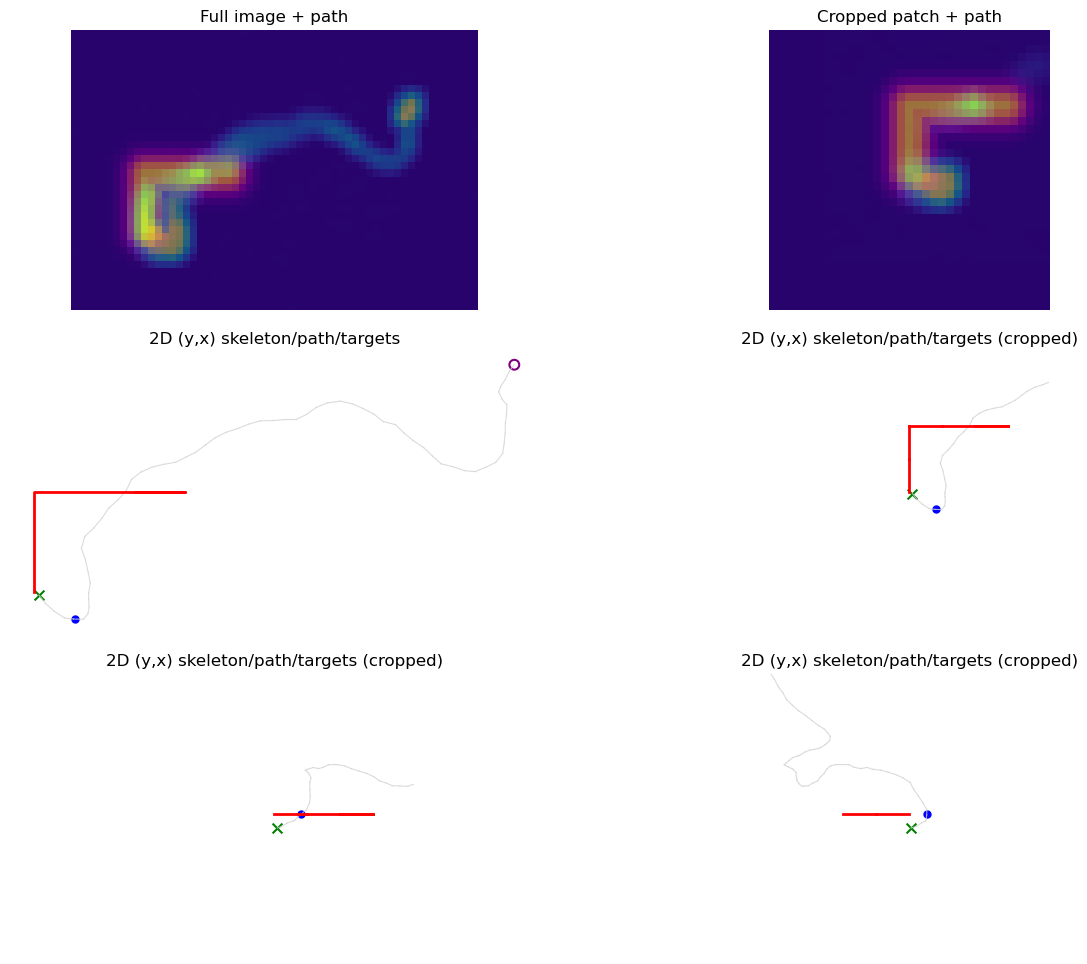

reward: tensor([-8.3383])
terminated: False


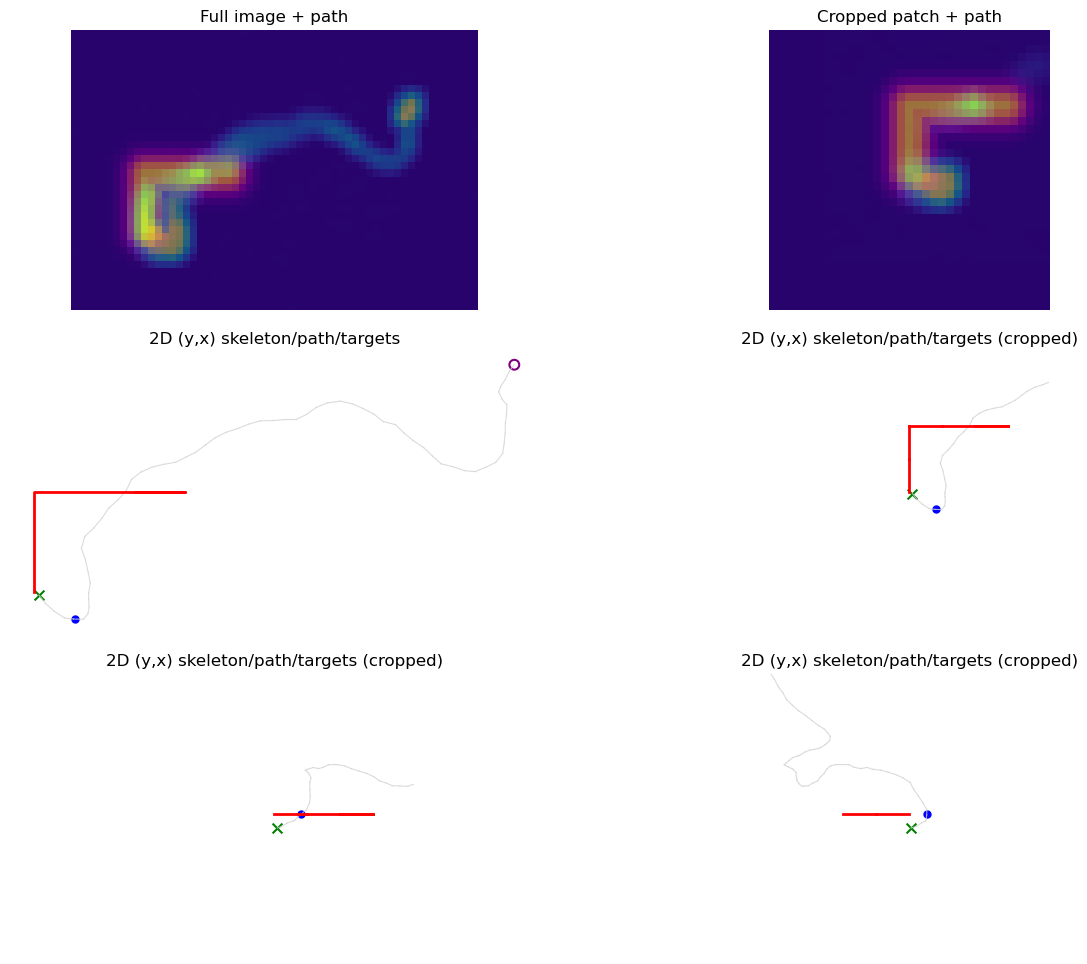

In [30]:
plt.close('all')
# env.img_idx = 1s
env.reset()
manual_step(env)

In [15]:
np.where(env.unvisited_tree[:,-1] == -1)

(array([0, 2]),)

In [24]:
np.linalg.norm(env.unvisited_tree[0, 2:5] - env.unvisited_tree[1, 2:5])

9.582942749670434e-05

In [23]:
env.visited

{(53.0, 55.0): 0.0}

In [ ]:
nearest_point, nearest_edge = tracking_reward._get_nearest_point(env.paths[env.head_id][-1], env.unvisited_tree, id_to_idx=env.id_to_idx, current_section_id=None)
target_points = tracking_reward._compute_target_point(env.paths[env.head_id][-1], env.unvisited_tree, id_to_idx=env.id_to_idx, step_size=env.step_size)

TO DO

1. There are certain occasions when some length of neuron is not removed when it should be.\
    Hint: My guess is there is an error where an edge is almost completely visited but is not removed because its coverage is slightly less than 1.
    There may be a rounding error when computing either the nearest point, or the coverage of an edge, or removing partially visited edges.
    Potentially the problem is that the path points are type float32 while the swc_list points are float64. I will make all points consistently float32.
2. Occasionally the error "ValueError: not enough values to unpack (expected 2, got 1)" occurs when calling "dist, closest_point = _distance_points_to_segment(point, nearest_node_pos, neighbor_pos)"\
in the middle of an episode for an unknown reason.\
    Solution: This was because _distance_points_to_segment returns only dist if the segment has length $< 1e-12$
3. What happens after all the neuron is visited and a step is taken instead of terminating?
4. Look into stopping a training episode when the path gets farther than the patch radius from the target and returning truncated rather than terminated.
